In [1]:
from photutils.datasets import make_100gaussians_image
data = make_100gaussians_image()

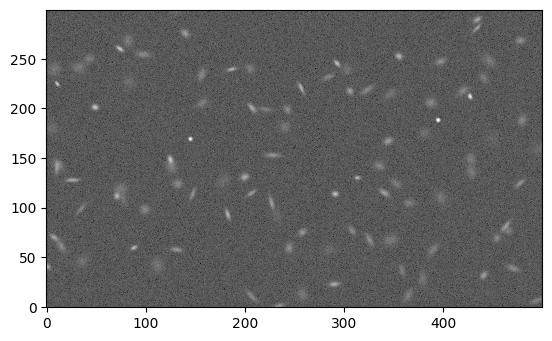

In [2]:
import matplotlib.pyplot as plt
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
norm = ImageNormalize(stretch=SqrtStretch())
plt.imshow(data, norm=norm, origin='lower', cmap='Greys_r',
           interpolation='nearest')

In [3]:
import numpy as np
from astropy.stats import biweight_location
print(np.median(data))  
print(biweight_location(data))  

5.222396450477202
5.187556943476142


add a gradient to the background

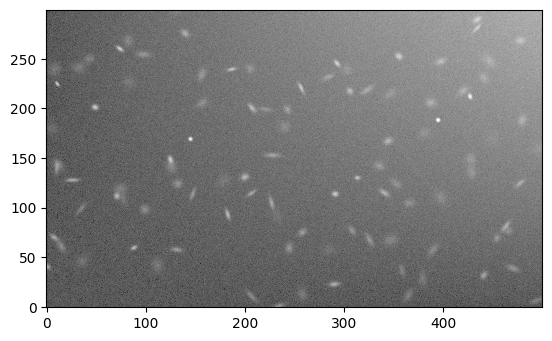

In [4]:
ny, nx = data.shape
y, x = np.mgrid[:ny, :nx]
gradient = x * y / 5000.0
data2 = data + gradient
plt.imshow(data2, norm=norm, origin='lower', cmap='Greys_r',
           interpolation='nearest')  

In [5]:
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground
sigma_clip = SigmaClip(sigma=3.0)
bkg_estimator = MedianBackground()
bkg = Background2D(data2, (50, 50), filter_size=(3, 3),
                   sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)

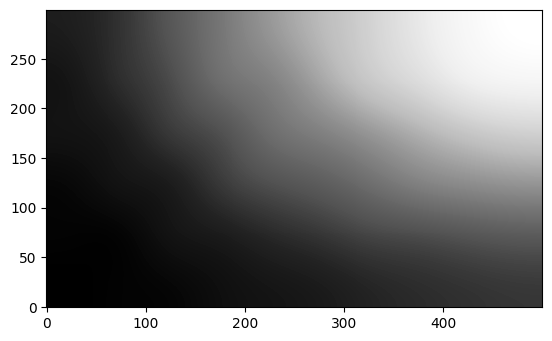

In [6]:
plt.imshow(bkg.background, origin='lower', cmap='Greys_r',
           interpolation='nearest')

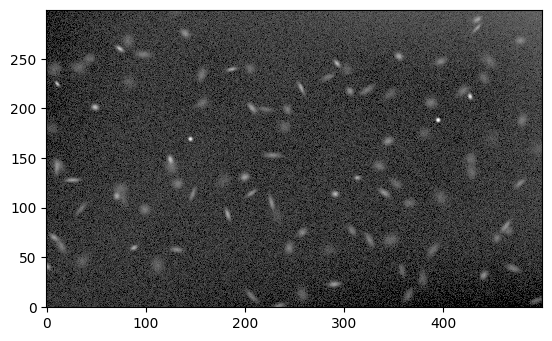

In [7]:
plt.imshow(data2 - bkg.background, norm=norm, origin='lower',
           cmap='Greys_r', interpolation='nearest')

Point source detections

In [8]:
import numpy as np
from astropy.stats import sigma_clipped_stats
from photutils.datasets import load_star_image
hdu = load_star_image()  
data = hdu.data[0:401, 0:401]  
mean, median, std = sigma_clipped_stats(data, sigma=3.0)  
print(np.array((mean, median, std)))  

[3668.09661146 3649.          204.41388592]


In [9]:
from photutils.detection import DAOStarFinder
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*std)  
sources = daofind(data - median)  
for col in sources.colnames:  
    if col not in ('id', 'npix'):
        sources[col].info.format = '%.2f'  # for consistent table output
sources.pprint(max_width=76)

 id xcentroid ycentroid sharpness ...   peak     flux    mag   daofind_mag
--- --------- --------- --------- ... ------- --------- ------ -----------
  1    144.25      6.38      0.58 ... 6903.00  45735.00 -11.65       -1.89
  2    208.67      6.82      0.48 ... 7896.00  62118.00 -11.98       -2.07
  3    216.93      6.58      0.69 ... 2195.00  12436.00 -10.24       -0.55
  4    351.63      8.55      0.49 ... 6977.00  55313.00 -11.86       -1.93
  5    377.52     12.07      0.52 ... 1260.00   9078.00  -9.89       -0.12
  6    294.27     12.74      0.68 ... 2059.00  15818.00 -10.50       -0.43
  7     85.22     14.71      0.62 ... 1458.00   7413.00  -9.67       -0.24
  8    137.94     17.46      0.54 ... 5451.00  38267.00 -11.46       -1.68
  9    130.33     18.68      0.63 ... 3432.00  19551.00 -10.73       -1.14
 10    143.11     18.62      0.52 ... 6722.00  48799.00 -11.72       -1.90
...       ...       ...       ... ...     ...       ...    ...         ...
277     92.38    393.25  

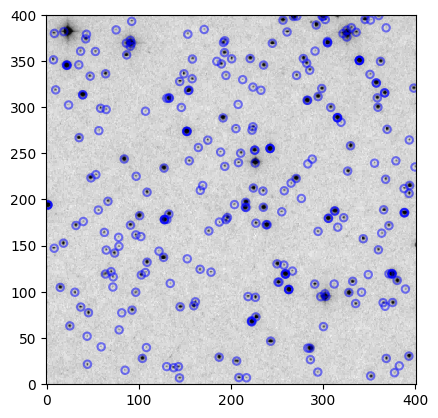

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from photutils.aperture import CircularAperture
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
apertures = CircularAperture(positions, r=4.0)
norm = ImageNormalize(stretch=SqrtStretch())
plt.imshow(data, cmap='Greys', origin='lower', norm=norm,
           interpolation='nearest')
apertures.plot(color='blue', lw=1.5, alpha=0.5)

local peak detection

In [11]:
from astropy.stats import sigma_clipped_stats
from photutils.datasets import make_100gaussians_image
from photutils.detection import find_peaks
data = make_100gaussians_image()
mean, median, std = sigma_clipped_stats(data, sigma=3.0)
threshold = median + (5.0 * std)
tbl = find_peaks(data, threshold, box_size=11)
tbl['peak_value'].info.format = '%.8g'  # for consistent table output
print(tbl[10:20])  # print only the first 10 peaks

 id x_peak y_peak peak_value
--- ------ ------ ----------
 11      0     41  37.107252
 12    112     42  17.821667
 13     35     44  17.964239
 14    132     57  27.673084
 15    392     57  18.102823
 16     88     58  38.213938
 17    244     58  26.273211
 18    345     63  16.204644
 19    325     67  23.283956
 20    455     68  22.431253


(0.0, 299.0)

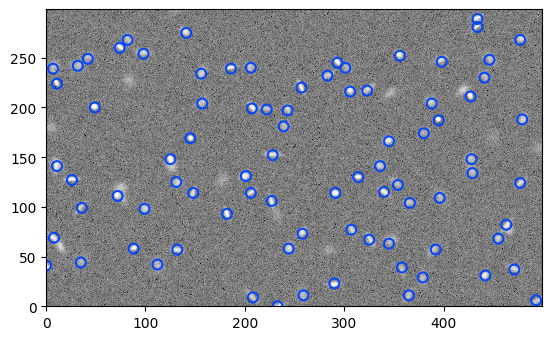

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from astropy.visualization.mpl_normalize import ImageNormalize
from photutils.aperture import CircularAperture
positions = np.transpose((tbl['x_peak'], tbl['y_peak']))
apertures = CircularAperture(positions, r=5.0)
norm = simple_norm(data, 'sqrt', percent=99.9)
plt.imshow(data, cmap='Greys_r', origin='lower', norm=norm,
           interpolation='nearest')
apertures.plot(color='#0547f9', lw=1.5)
plt.xlim(0, data.shape[1] - 1)
plt.ylim(0, data.shape[0] - 1)

In [13]:
from photutils.centroids import centroid_quadratic
xycen = centroid_quadratic(data, xpeak=88, ypeak=58) #88     58
print(xycen)  

[88.71229247 58.70431563]


In [20]:
from photutils.profiles import RadialProfile
edge_radii = np.arange(25)
error = np.zeros_like(data) + 2.4
rp = RadialProfile(data, xycen, edge_radii, error=error, mask=None)

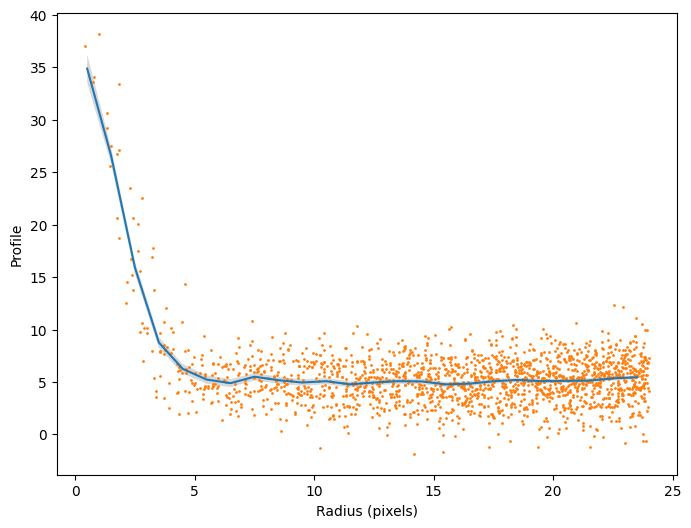

In [21]:
# normnalize the radial profile
#rp.normalize(method='max')
# plot the radial profile
fig, ax = plt.subplots(figsize=(8, 6))
rp.plot(ax=ax, color='C0')
rp.plot_error(ax=ax)
ax.scatter(rp.data_radius, rp.data_profile, s=1, color='C1')

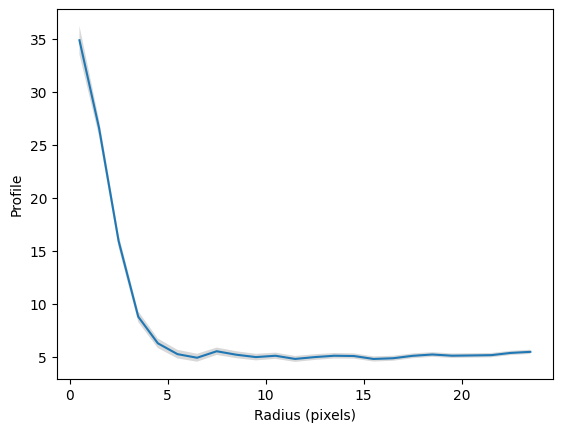

In [22]:
rp.plot(label='Radial Profile')
rp.plot_error()

fit with Gaussian fwhm

In [25]:
rp.gaussian_fit  
print(rp.gaussian_fwhm)

5.3220240901403155


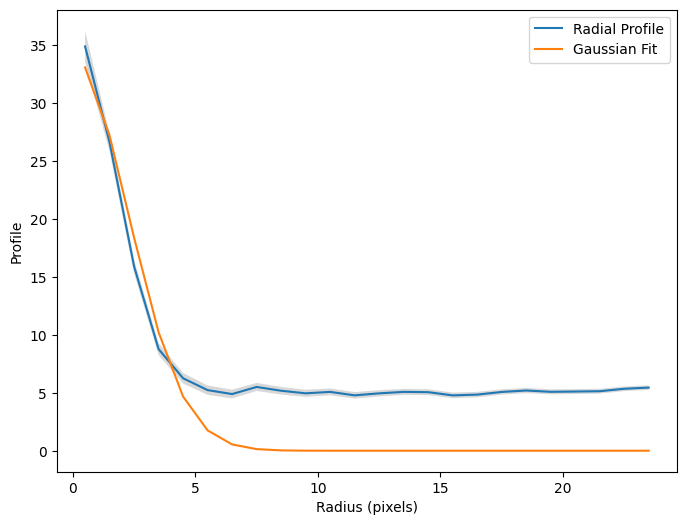

In [26]:
# plot the radial profile
fig, ax = plt.subplots(figsize=(8, 6))
rp.plot(ax=ax, label='Radial Profile')
rp.plot_error(ax=ax)
ax.plot(rp.radius, rp.gaussian_profile, label='Gaussian Fit')
ax.legend()